# 1. Dataset Selection

We get the data from Kaggle: [Vehicle Sales Data](https://www.kaggle.com/datasets/syedanwarafridi/vehicle-sales-data/data)


**Dataset Description:**
The " Vehicle Sales Data on used car market " provides a comprehensive collection of information pertaining to the sales transactions of various vehicles. This dataset encompasses details such as the year, make, model, trim, body type, transmission type, VIN (Vehicle Identification Number), state of registration, condition rating, odometer reading, exterior and interior colors, seller information, Manheim Market Report (MMR) values, selling prices, and sale dates.

**Key Features:**
Vehicle Details: Includes specific information about each vehicle, such as its make, model, trim, and manufacturing year.
Transaction Information: Provides insights into the sales transactions, including selling prices and sale dates.
Market Trends: MMR values offer an estimate of the market value of each vehicle, allowing for analysis of market trends and fluctuations.
Condition and Mileage: Contains data on the condition of the vehicles as well as their odometer readings, enabling analysis of how these factors influence selling prices.


install the library and input date from google share file

In [ ]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Load dataset
# this code can download the dataset from Ryan's google drive. So we can run all the code in this Colab.
!gdown --id '1CxRwCLhfIAmnoAb9cn8xahRrrmuIaGXe' --output used_car_price_Modelling.csv
# List all files in the current directory
!ls
df = pd.read_csv('used_car_price_Modelling.csv')
df.head()

/usr/local/lib/python3.10/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1CxRwCLhfIAmnoAb9cn8xahRrrmuIaGXe
To: /content/used_car_price_Modelling.csv
100% 88.0M/88.0M [00:01<00:00, 52.6MB/s]
clean_df.csv  sample_data  used_car_price_Modelling.csv


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB


In [ ]:
print("Size of the dataset:", df.shape)
print(f'Number of rows: {df.shape[0]}, number of columns: {df.shape[1]}')

Size of the dataset: (558837, 16)
Number of rows: 558837, number of columns: 16


In [ ]:
df.drop(['vin','model'],axis=1, inplace=True)

**The reason why we drop these columns**:

**vin**: It is vehicle ID, we do need to use it for our predictive model

**model**: model & body present the same information what category is this car. Each brand iust using differnet model name to describe therefor we will drop (model) column from our data. (Body) has duplication for example SUV & suv.

---



In [ ]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numeric columns:", numeric_columns)

categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
print("Category columns:", categorical_columns)

Numeric columns: ['year', 'condition', 'odometer', 'mmr', 'sellingprice']
Category columns: ['make', 'trim', 'body', 'transmission', 'state', 'color', 'interior', 'seller', 'saledate']


**Numeric columns:**

- year: Integer type (int64) - represents the manufacturing year

- condition, odometer, mmr, sellingprice: Floating point (float64)

- condition: likely a numeric rating

- odometer: mileage reading

- mmr: Manheim Market Report value

- sellingprice: final sale price

**Categorical columns (object type):**

- make: Vehicle manufacturer

- trim: Trim level

- body: Body style

- transmission: Transmission type

- state: Location state

- color: Exterior color

- interior: Interior color/material

- seller: Seller information

- saledate: Date of sale (stored as text) we will change it into datetime type

Car sales dataset consist of with both numerical features and categorical features.

#2. Data Exploration

## Missing value

In [ ]:
# Count of missing values per column
missing_values = df.isna().sum()

# Percentage of missing values
missing_percent = (missing_values / len(df)) * 100

# Create a summary table
missing_summary = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percent
}).sort_values(by='Percentage', ascending=False)

# Display the summary table
missing_summary[missing_summary['Percentage']>0]

,Missing Values,Percentage
transmission,65352,11.694287
body,13195,2.361154
condition,11820,2.115107
trim,10651,1.905922
make,10301,1.843292
color,749,0.134028
interior,749,0.134028
odometer,94,0.016821
mmr,38,0.006800
sellingprice,12,0.002147


msno.bar calculates the percentage of non-null values for each column. Creates a bar chart where:

Each bar represents a column in DataFrame

Height shows the proportion of complete (non-null) values

Additional axes show actual counts of complete values

In the output it can be said that transmission attribute has the most missing values.

<Axes: >

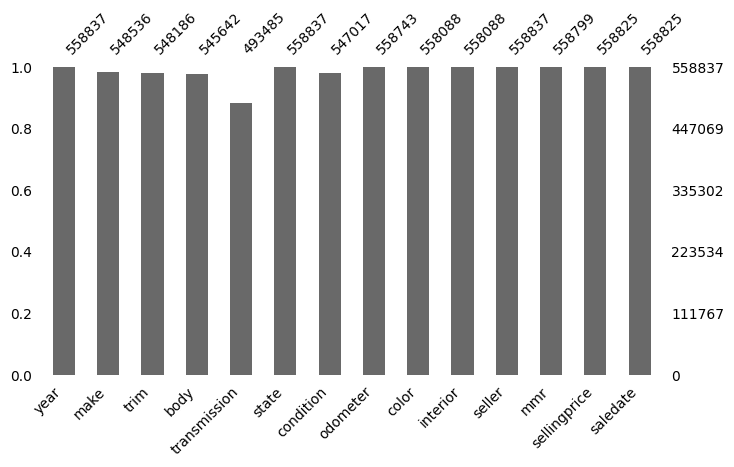

In [ ]:
import missingno as msno

msno.bar(df = df, figsize = (8, 4), fontsize = 10)

From the output of the matrix we can catch a relation between make, model, trim and body attributes. This means if any of these attributes is missing then the others tend to do so.

<Axes: >

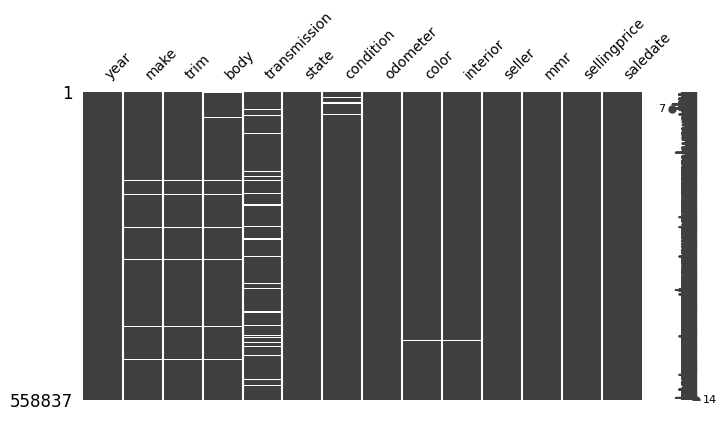

In [ ]:
msno.matrix(df, figsize=(8, 4), fontsize=10)

We start cleaning data from bottom

**color, interior, odometer, mmr, sellingprice, saledate**:
Low Percentage of Missing Values < 1%

**Approach:** Listwise Deletion: Removing entire rows where any data is missing. Simple but can lead to significant data loss.

In [ ]:
# Drop rows where any of the specified columns have missing values
df.dropna(subset=['color', 'odometer', 'mmr', 'sellingprice', 'saledate'], inplace=True)

**body, trim, make**: Create a dictionary to store the mode of each column

In [ ]:
value = {}
for col in ['body','trim', 'make']:
    value[col] = df[col].mode().iloc[0]  # Store the mode for each column

# Fill missing values in categorical columns with their respective mode
df.fillna(value=value, inplace=True)

**condition** have positive relationship with (year), so we use average condition score by year to fill na value.

In [ ]:
# Define a function to get the mode for each group
def fill_with_group_mode(series):
    return series.fillna(series.mode()[0])

# Group by 'year' and apply the mode-filling function to the 'condition' column
df['condition'] = df.groupby('year')['condition'].transform(fill_with_group_mode)


**transmission** has highest percentage of missing value > 10% therefor we fill missing values with probabilistic choice based on distribution

In [ ]:
# Get the proportions of 'automatic' and 'manual'
transmission_probs = df['transmission'].value_counts(normalize=True)

# Extract the index (categories) and corresponding probabilities
transmission_categories = transmission_probs.index.tolist()
probabilities = transmission_probs.values

# Fill missing values in the 'transmission' column based on the observed probabilities
df['transmission'] = df['transmission'].apply(lambda x: np.random.choice(transmission_categories, p=probabilities) if pd.isnull(x) else x)

In [ ]:
# Count of missing values per column
print(df.isna().sum())

year            0
make            0
trim            0
body            0
transmission    0
state           0
condition       0
odometer        0
color           0
interior        0
seller          0
mmr             0
sellingprice    0
saledate        0
dtype: int64


##Numeric feature

In [ ]:
# Selecting numeric columns and calculating summary statistics with specific percentiles
numeric_df = df[numeric_columns]
numeric_df.describe(percentiles=[ 0.25, 0.5, 0.75]).round(2).T

,count,mean,std,min,25%,50%,75%,max
year,557963.0,2010.04,3.97,1982.0,2007.0,2012.0,2013.0,2015.0
condition,557963.0,30.46,13.39,1.0,23.0,34.0,41.0,49.0
odometer,557963.0,68348.33,53384.04,1.0,28392.5,52295.0,99148.0,999999.0
mmr,557963.0,13759.09,9657.92,25.0,7100.0,12250.0,18300.0,182000.0
sellingprice,557963.0,13601.24,9725.95,1.0,6900.0,12100.0,18200.0,230000.0


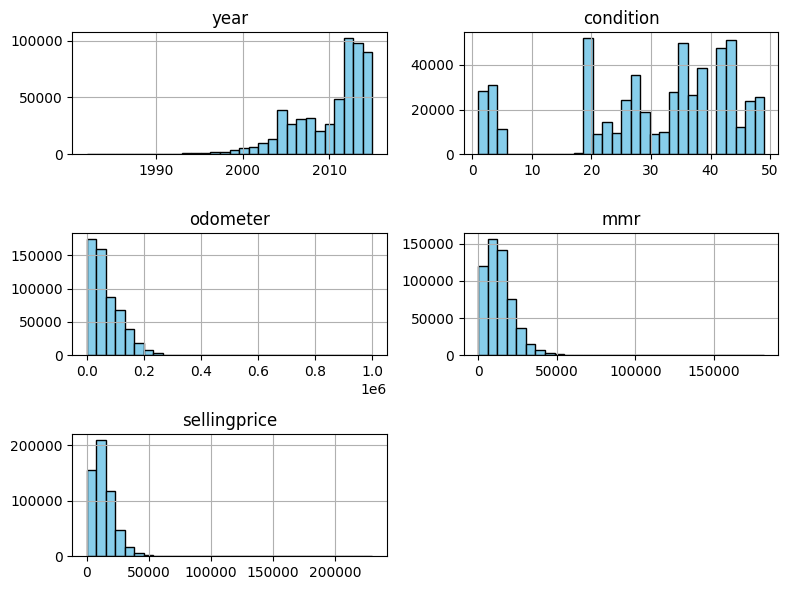

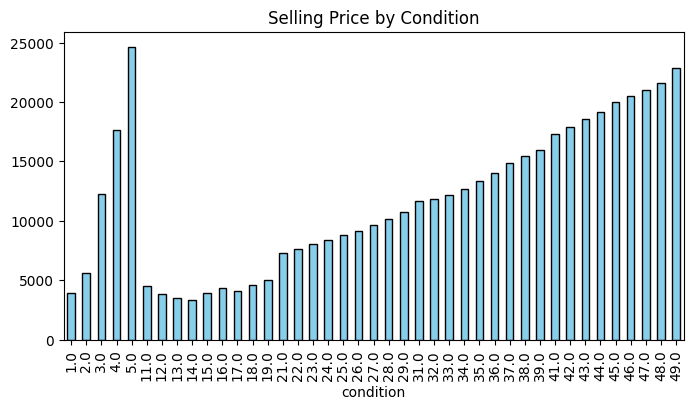

In [ ]:
df[numeric_columns].hist(bins=30, figsize=(8, 6), layout=(3, 2), color='skyblue', edgecolor='black')
plt.tight_layout()
plt.show()

numeric_df.groupby('condition')['sellingprice'].mean().plot(kind='bar', title='Selling Price by Condition',figsize=(8,4),color='skyblue', edgecolor='black')
plt.show()

**Numeric features observe**
1. In mmr, odometer and sellingprice, seems they have some signifcant outliers. we need to clear up them. (we will do it in the Data Cleaning and Preprocessing section.)

2. condtion: there are missing values between 6 and 10. 0 to 5 surpose to be bad condition, but look at the average price, condition 5 is highest. After we searched some infornations. There are two type of condition score systoms, one is 1 to 5, Another is 11 to 50. So we deside seperate them into two different dataframe.

In [ ]:
df_1to5 = df[df['condition']<=5]
df=df[df['condition']>5]

##Category Feature

Change the saledate datatype, before explore the data

In [ ]:
from datetime import datetime
import re

# Function to parse date by handling time zones
def parse(date_str):
    if isinstance(date_str, str):
        # Remove the time zone abbreviation (e.g., "(PST)") using regex
        clean_str = re.sub(r"\s\([A-Z]+\)$", "", date_str)
        # Parse the cleaned string
        try:
            return datetime.strptime(clean_str, "%a %b %d %Y %H:%M:%S GMT%z").date()
        except ValueError:
            return pd.NaT
    else:
        return pd.NaT

# Apply the function to each entry in the 'saledate' column
df['saledate'] = df['saledate'].apply(parse)

df['saledate'] = pd.to_datetime(df['saledate'], errors='coerce')

In [ ]:
for col in categorical_columns:
  print(df[col].value_counts(normalize=True), '\n')

make
Ford          0.188998
Chevrolet     0.101620
Nissan        0.100556
Toyota        0.073368
Dodge         0.050573
                ...   
chev truck    0.000002
hyundai tk    0.000002
mazda tk      0.000002
dodge tk      0.000002
Lotus         0.000002
Name: proportion, Length: 94, dtype: float64 

trim
Base                 0.119044
SE                   0.079710
LX                   0.037126
Limited              0.032713
XLT                  0.030561
                       ...   
L W12 6.3 quattro    0.000002
2wd ext              0.000002
fwd ext              0.000002
4x4 v6 nbx           0.000002
EWB                  0.000002
Name: proportion, Length: 1868, dtype: float64 

body
Sedan          0.378030
SUV            0.214486
sedan          0.077133
suv            0.044910
Hatchback      0.038644
                 ...   
q60 coupe      0.000006
g37 coupe      0.000002
CTS-V Wagon    0.000002
Ram Van        0.000002
cab plus 4     0.000002
Name: proportion, Length: 85, dtype: float

In [ ]:
for col in categorical_columns:
  print(f"{col}: {df[col].nunique()}")

make: 94
trim: 1868
body: 85
transmission: 2
state: 38
color: 20
interior: 17
seller: 13233
saledate: 167


**Catergory Feature Oberve**

Each column has various unique numbers and they have their onw issues need to handle.
* **make:** has duplication for example Ford & ford and group them by country.

* **body:** has duplication for example SUV & suv, and group them by similar type.

* **trim:** too many trims, it is difficalt to analyize, so we drop this columns.

* **transmission**: it surpose to be dummy value auyomatic as 1, manual as 0, and remove others(sedan, Sedan).

* **color**: there are some color called '-' , we will remove it.

* **seller**: too many sellers, it is difficalt to analyize, so we drop this columns.

* **saledate**: we need transfer it into date formate

In [ ]:
df.drop(['trim', 'seller'], axis=1, inplace=True)

In [ ]:
df['make'] = df['make'].str.lower()

In [ ]:
make_to_country = {
    # German Brands
    'bmw': 'Germany', 'audi': 'Germany', 'mercedes-benz': 'Germany', 'mercedes': 'Germany',
    'mercedes-b': 'Germany', 'volkswagen': 'Germany', 'vw': 'Germany', 'porsche': 'Germany',
    'bentley': 'Germany', 'smart': 'Germany',

    # Swedish Brands
    'volvo': 'Sweden', 'saab': 'Sweden',

    # British Brands
    'aston martin': 'United Kingdom', 'rolls-royce': 'United Kingdom', 'land rover': 'United Kingdom',
    'landrover': 'United Kingdom', 'jaguar': 'United Kingdom', 'mini': 'United Kingdom', 'lotus': 'United Kingdom',

    # Italian Brands
    'fiat': 'Italy', 'maserati': 'Italy', 'ferrari': 'Italy', 'lamborghini': 'Italy',

    # American Brands
    'ford': 'United States', 'ford tk': 'United States', 'dodge': 'United States', 'dodge tk': 'United States',
    'chevrolet': 'United States', 'cadillac': 'United States', 'buick': 'United States', 'gmc': 'United States',
    'gmc truck': 'United States', 'pontiac': 'United States', 'saturn': 'United States', 'chrysler': 'United States',
    'jeep': 'United States', 'ram': 'United States', 'mercury': 'United States', 'oldsmobile': 'United States',
    'hummer': 'United States', 'lincoln': 'United States', 'plymouth': 'United States', 'tesla': 'United States',
    'geo': 'United States', 'fisker': 'United States',

    # Japanese Brands
    'toyota': 'Japan', 'honda': 'Japan', 'nissan': 'Japan', 'mitsubishi': 'Japan', 'mazda': 'Japan',
    'subaru': 'Japan', 'suzuki': 'Japan', 'lexus': 'Japan', 'infiniti': 'Japan', 'acura': 'Japan',
    'scion': 'Japan', 'isuzu': 'Japan', 'dot': 'Japan',

    # South Korean Brands
    'kia': 'South Korea', 'hyundai': 'South Korea', 'daewoo': 'South Korea'
}

# Applying the mapping to create a new column 'country'
df['make'] = df['make'].map(make_to_country)


body

In [ ]:
df['body'] = df['body'].str.lower()

# Grouping the vehicle types
vehicle_groups = {
    'Sedans and Coupes': [
        'sedan', 'coupe', 'g coupe', 'g sedan', 'elantra coupe', 'genesis coupe',
        'cts coupe', 'cts-v coupe', 'g37 coupe', 'q60 coupe', 'tsx sport wagon'
    ],
    'SUVs and Crossovers': [
        'suv', 'hatchback', 'wagon'
    ],
    'Convertibles': [
        'convertible', 'g convertible', 'g37 convertible', 'q60 convertible',
        'beetle convertible', 'granturismo convertible'
    ],
    'Minivans and Vans': [
        'minivan', 'van', 'e-series van', 'promaster cargo van', 'ram van',
        'transit van'
    ],
    'Pickup Trucks': [
        'crew cab', 'double cab', 'crewmax cab', 'access cab', 'king cab',
        'supercrew', 'extended cab', 'supercab', 'regular cab', 'quad cab',
        'club cab', 'xtracab', 'cab plus', 'cab plus 4', 'mega cab', 'regular-cab'
    ],
    'Station Wagons': [
        'cts wagon', 'cts-v wagon'
    ],
    'Special Models': [
        'koup', 'cts-v coupe', 'tsx sport wagon'
    ],
    'Uncategorized': [
        None
    ]
}

# Creating a dictionary to map body types to their groups
body_to_group = {}
for group, body_types in vehicle_groups.items():
    for body_type in body_types:
        body_to_group[body_type] = group

# Applying the mapping to create a new column 'body_group'
df['body'] = df['body'].map(body_to_group)

transmissions

In [ ]:
# Function to categorize transmissions
df['transmission'] = df['transmission'].apply(lambda x: 1 if str(x).lower() == 'automatic' else 0 if str(x).lower() == 'manual' else pd.NA).astype('Int64')

color

In [ ]:
df = df.loc[df['color'] != '—']

Saledate Range

In [ ]:
df['saledate'].agg(['min', 'max'])

,saledate
min,2014-01-01
max,2015-07-21


## Data Visualization

Color, most of colors' distribution is similar. and black and charcaol have higher average sale price.

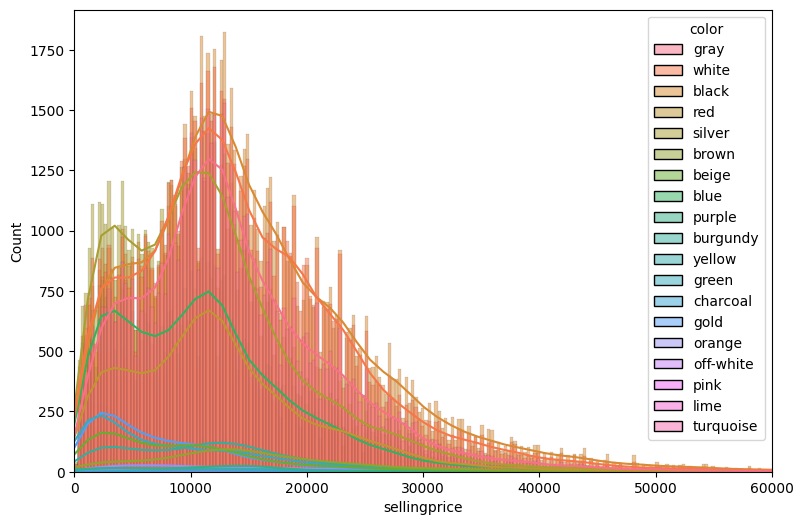

In [ ]:
# Set the figure size before calling Seaborn's plotting function
plt.figure(figsize=(9, 6))

sns.histplot(data=df, x="sellingprice", kde=True, hue="color")

plt.xlim(0, 60000)

plt.show()

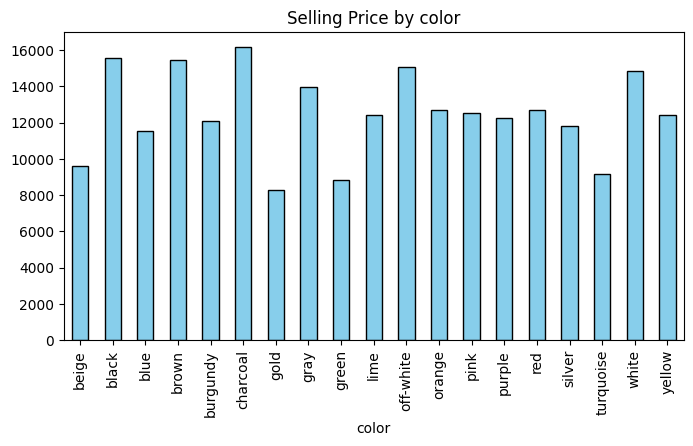

In [ ]:
df.groupby('color')['sellingprice'].mean().plot(kind='bar', title='Selling Price by color',figsize=(8,4),color='skyblue', edgecolor='black')
plt.show()

interior, the cars that have off-white of interior has highest average sale price.

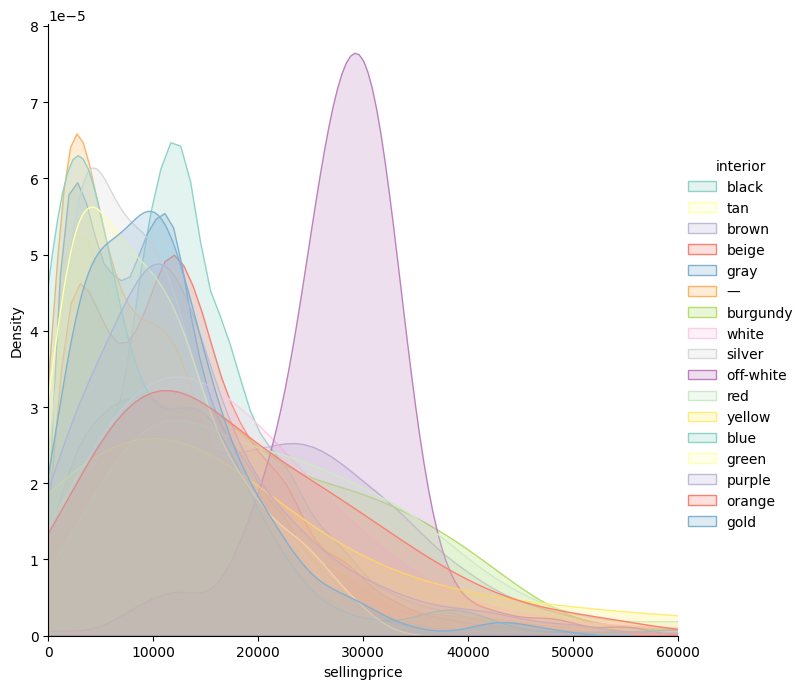

In [ ]:
sns.FacetGrid(data = df, hue = "interior",height = 7,
              xlim = (0, 60000), palette="Set3").map(sns.kdeplot, "sellingprice", fill = True).add_legend()

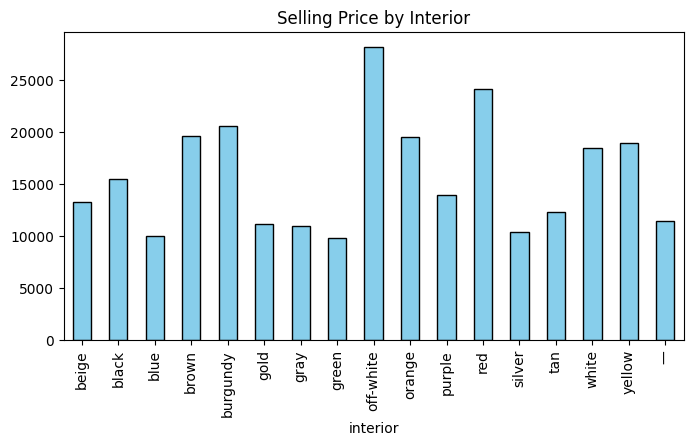

In [ ]:
df.groupby('interior')['sellingprice'].mean().plot(kind='bar', title='Selling Price by Interior',figsize=(8,4),color='skyblue', edgecolor='black')
plt.show()

MMR, sellingprice relationship. they have opsitive linear relationship.

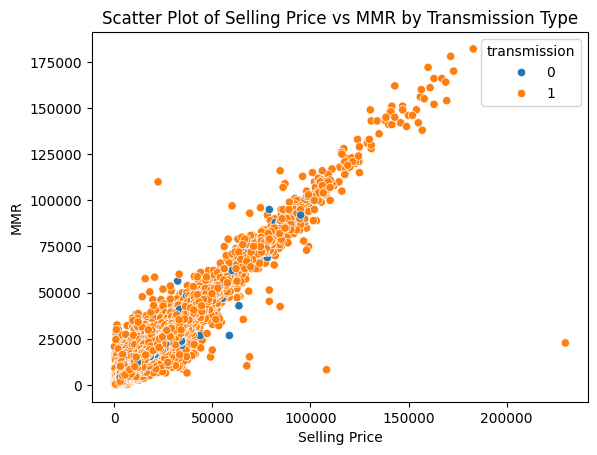

In [ ]:
# Create the scatter plot with updated transmission labels
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df, x="sellingprice", y="mmr", hue="transmission")
plt.xlabel('Selling Price')
plt.ylabel('MMR')
plt.title('Scatter Plot of Selling Price vs MMR by Transmission Type')
plt.show()


0 is automatic and 1 is manual in the 'transmission' column

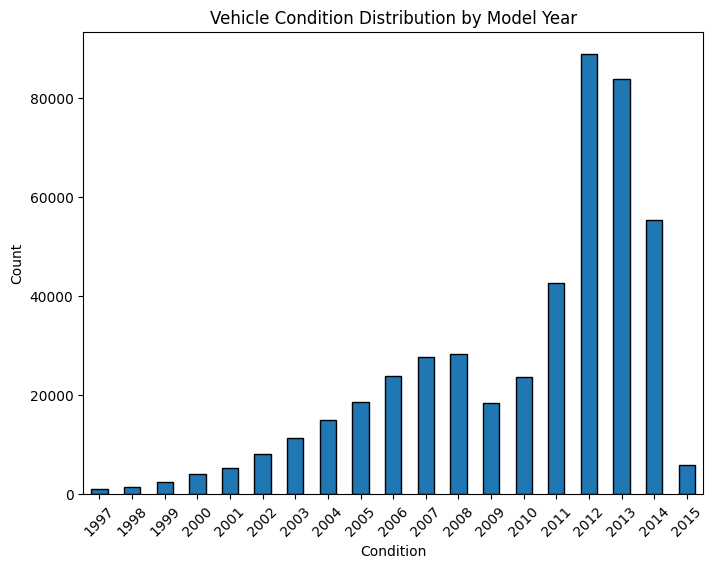

In [ ]:
# Plot the bar chart
plt.figure(figsize=(8, 6))# Define the fraction of data to keep

# Perform stratified sampling by each year and exclude grouping columns explicitly
df.groupby('year', group_keys=False, as_index=False)

df['year'].value_counts().sort_index().plot(kind='bar', edgecolor='black')
plt.title('Vehicle Condition Distribution by Model Year')
plt.xlabel('Condition')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

The population of the 2008-2009 model has decreased. The financial crisis adversely affected the economy, resulting in a decline in car demand in 2008 and 2009.

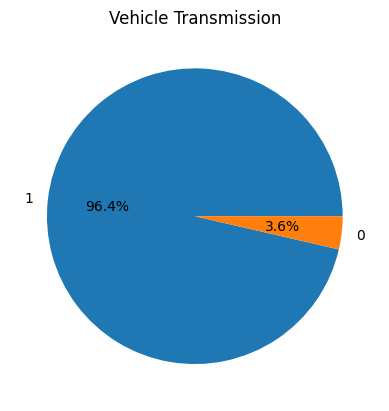

In [ ]:
# Plotting the pie chart for the 'transmission' column value counts
df['transmission'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Vehicle Transmission')
plt.ylabel('')  # Remove y-axis label for better presentation
plt.show()


#3. Data Cleaning and Preprocessing

## Outlier

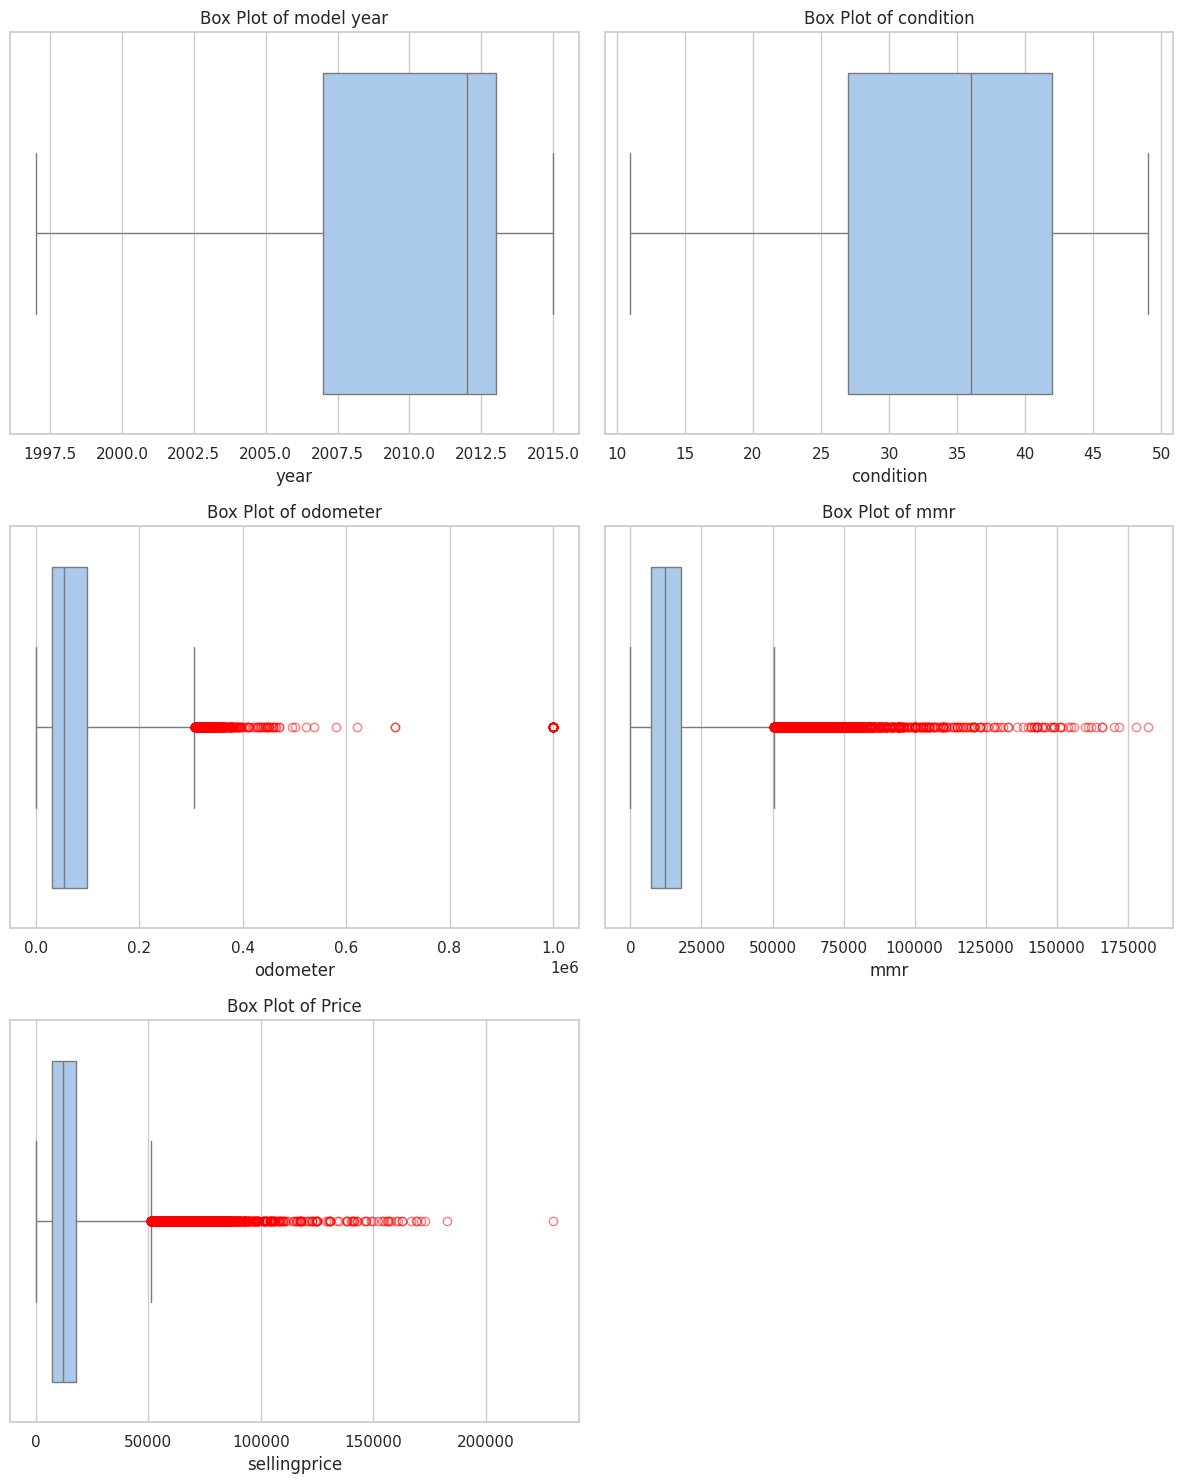

In [ ]:
import seaborn as sns

# Define the columns you want to plot, which are numerical and meaningful for outliers detection
numerical_columns = ['year', 'condition', 'odometer', 'mmr', 'sellingprice']

# Set the aesthetic style of the plots (optional)
sns.set_style("whitegrid")  # Other options include: darkgrid, white, dark, ticks
sns.set_context("notebook")  # Other options include: paper, notebook, talk, poster
sns.set_palette("pastel")  # Other options include: deep, muted, bright, dark, colorblind

# Create a figure and a set of subplots with a 3x2 grid (sufficient for 5 plots)
fig, axes = plt.subplots(3, 2, figsize=(12, 15))

# Define flier properties to make outliers red
flierprops = flierprops=dict(marker='o', markeredgecolor='red', alpha=0.5)

sns.boxplot(x=df['year'], ax=axes[0, 0], whis=3, flierprops=flierprops)
axes[0, 0].set_title('Box Plot of model year')

sns.boxplot(x=df['condition'], ax=axes[0, 1], whis=3, flierprops=flierprops)
axes[0, 1].set_title('Box Plot of condition')

sns.boxplot(x=df['odometer'], ax=axes[1, 0], whis=3, flierprops=flierprops)
axes[1, 0].set_title('Box Plot of odometer')

sns.boxplot(x=df['mmr'], ax=axes[1, 1], whis=3, flierprops=flierprops)
axes[1, 1].set_title('Box Plot of mmr')

sns.boxplot(x=df['sellingprice'], ax=axes[2, 0], whis=3, flierprops=flierprops)
axes[2, 0].set_title('Box Plot of Price')

# Hide the empty subplot (last one, which has no plot)
fig.delaxes(axes[2, 1])

# Display the plots
plt.tight_layout()
plt.show()



In [ ]:
# Dictionary to hold the count of outliers for each column
outliers_count = {}

# Loop through each numerical column to calculate outliers
for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    # Define bounds for outliers
    lower_bound = Q1 - 3 * IQR
    upper_bound = Q3 + 3 * IQR

    # Count outliers
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    outliers_count[column] = len(outliers)

# Print the results
print("Outliers count per feature:")
for key, value in outliers_count.items():
    percen = round((value / len(df)) * 100, 2)
    print(f"{key}: {value} ({percen}%)")


Outliers count per feature:
year: 0 (0.0%)
condition: 0 (0.0%)
odometer: 417 (0.09%)
mmr: 2569 (0.55%)
sellingprice: 2387 (0.51%)


Delete the outliers

In [ ]:
# Loop through each numerical column to calculate outliers
for column in numerical_columns:
    # Calculate the 1st and 3rd quartiles
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    # Define bounds for outliers (3 * IQR)
    lower_bound = Q1 - 3 * IQR
    upper_bound = Q3 + 3 * IQR

    # Filter out rows that fall outside the bounds
    df = df[(df[column] > lower_bound) & (df[column] < upper_bound)]

##One Hot Encoding

In [ ]:
# Ensure that the 'saledate' column is of datetime type
df['saledate'] = pd.to_datetime(df['saledate'])

# Create a new column 'weekday' with values from 1 (Monday) to 7 (Sunday)
df['weekday'] = df['saledate'].dt.weekday + 1


In [ ]:
df1 = df.copy()

In [ ]:
# Applying one-hot encoding to the columns 'body', 'make', and 'color'
df1 = pd.get_dummies(df1, columns=["body"], prefix=["Cat"])
df1 = pd.get_dummies(df1, columns=["make"], prefix=["Brand"])
df1 = pd.get_dummies(df1, columns=["color"], prefix=["C"])
df1 = pd.get_dummies(df1, columns=["interior"], prefix=["I"])

# Converting the dummy columns to Int64 type
dummy_columns = df1.columns[df1.columns.str.startswith('Cat_') | df1.columns.str.startswith('Brand_') | df1.columns.str.startswith('C') | df1.columns.str.startswith('I') ]
df1[dummy_columns] = df1[dummy_columns].astype('int64')

In [ ]:
df1.shape

(461705, 59)

##Heat Map

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

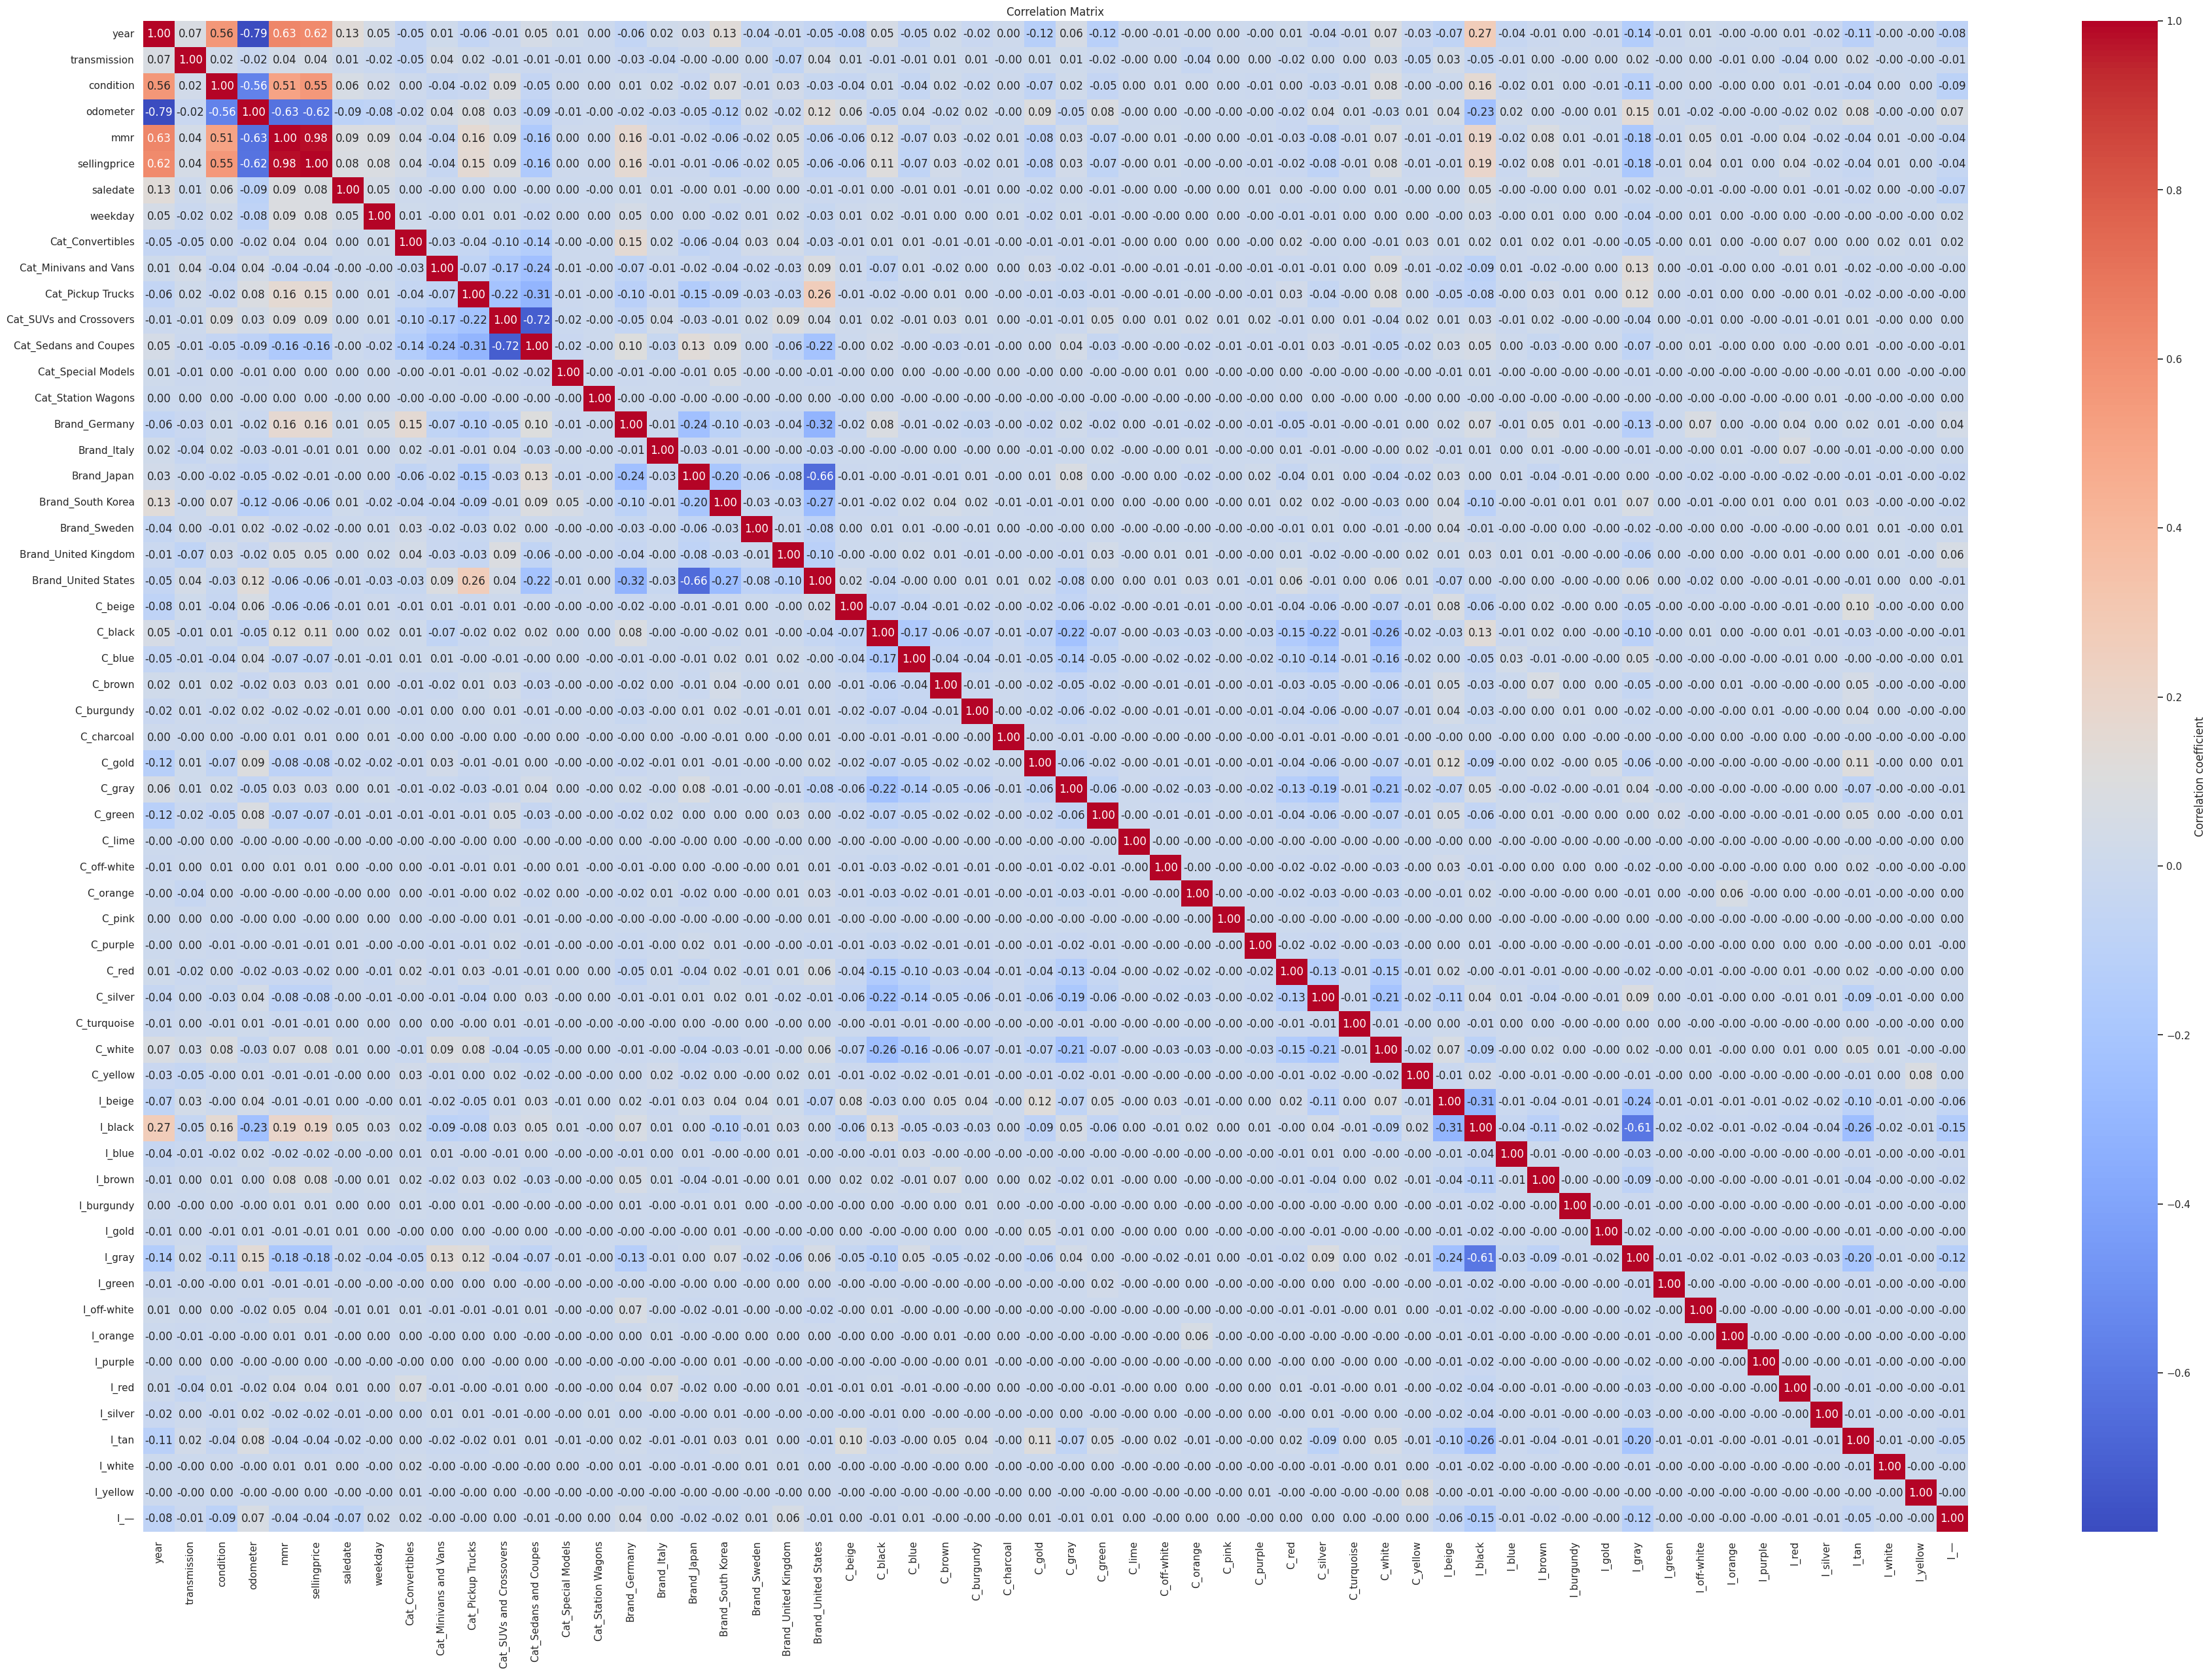

In [ ]:
# Select numerical columns from the DataFrame
df_n = df1.select_dtypes(['float64', 'int64', 'int32','datetime64[ns]' ])

# Calculate the correlation matrix
corr_matrix = df_n.corr()

# Plot the correlation matrix using a heatmap
plt.figure(figsize=(45, 30))  # Set the size of the figure
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm',
            cbar_kws={'label': 'Correlation coefficient'})
plt.title('Correlation Matrix')
plt.show()

We just don't want to overlook any potential influences on sellingprices. However, it's clear that the most of them have little impact on price, therefore we remove the majority.

**Only "year," "condition," "odometer," "mmr," "Cat_Pickup Trucks," "Brand_Germany," "C_black," "I_gray," and "sellingprice" remain.**

In [ ]:
clean_df = df1[['year','condition','odometer','mmr','Cat_Pickup Trucks', 'Brand_Germany', 'C_black','I_gray', 'sellingprice']]

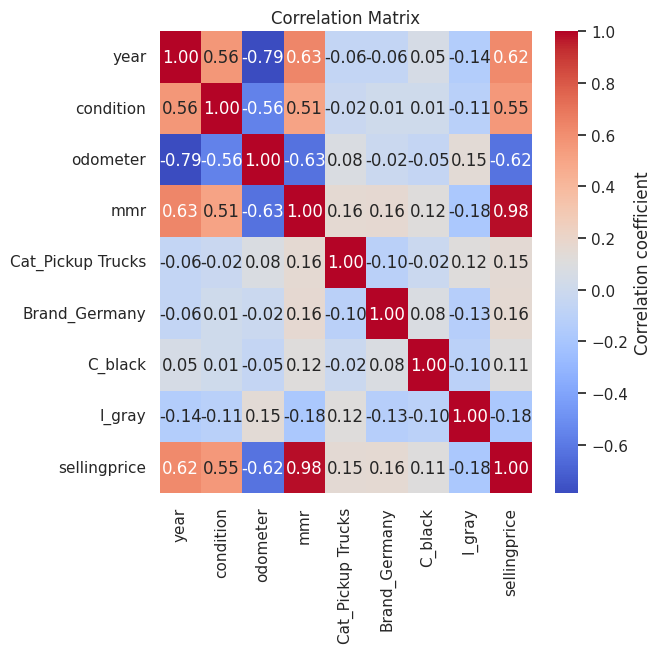

In [ ]:
# Select numerical columns from the DataFrame
df_n = clean_df.select_dtypes(['float64', 'int64', 'int32'])

# Calculate the correlation matrix
corr_matrix = df_n.corr()

# Plot the correlation matrix using a heatmap
plt.figure(figsize=(6, 6))  # Set the size of the figure
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm',
            cbar_kws={'label': 'Correlation coefficient'})
plt.title('Correlation Matrix')
plt.show()

In [ ]:
clean_df.to_csv('clean_df.csv', index=False)

#4. Identifying Business Analytics Questions
Based on the data and domain, identify 2-3 key business analytics questions your group aims to answer. Clearly state each question, explaining why it is relevant to the data and potential stakeholders.

A car dealership wants to optimize its pricing strategy to maximize profits while remaining competitive in the market. The dealership has a large dataset containing detailed information about past vehicle sales, including attributes such as make, model, year, condition, odometer reading, and selling price. By analyzing this dataset, the dealership aims to develop a predictive model that can accurately estimate the selling price of vehicles based on their features.

Expected Outcomes

- A comprehensive understanding of the factors influencing vehicle selling prices.
- A robust predictive model that can estimate vehicle prices with high accuracy.
- Improved pricing strategy leading to increased profitability and competitiveness for the dealership.

**Business Analytics Questions:**

**1. What are the key factors that influence the selling price of used vehicles?**

- Relevance: Understanding which factors (e.g., year, condition, odometer, MMR value, vehicle type, color, etc.) have the most significant impact on selling prices can help dealerships set competitive and optimized pricing strategies.

- Stakeholders: Pricing analysts, dealership managers, and marketing teams can use these insights to tailor pricing models and promotional strategies.

**2. How can we accurately predict the selling price of a vehicle based on its features?**

- Relevance: Building a predictive model to estimate vehicle prices will enable the dealership to assess the fair market value of a car, aiding in quicker inventory turnover and customer trust.

- Stakeholders: Dealership operations, finance teams, and sales representatives can use this model for real-time pricing during negotiations and inventory evaluations.

**3. What trends and patterns exist in vehicle sales over time, and how do these trends vary across different segments?**

- Relevance: Analyzing sales trends (e.g., seasonality, demand for specific vehicle types, or price sensitivity by brand) will allow the dealership to make data-driven decisions about inventory management and marketing campaigns.

- Stakeholders: Inventory planners, marketing teams, and dealership executives can use these trends to optimize stock and target promotions effectively.

***Expected Outcomes:***

- A comprehensive understanding of the variables most strongly influencing vehicle selling prices, such as condition, odometer, and market value (MMR).

- A reliable predictive model with actionable insights, capable of providing price estimates with high accuracy, to assist in decision-making for pricing and inventory.

- Identification of market trends and customer preferences that can inform strategies for promotions, marketing, and inventory management, leading to improved profitability and competitiveness.

# 5. Predictive Model

## Lasso Regression
Before you run this model, please run step1(dataset selection) to step3(Data Cleaning and Preprocessing), because this training dataset is from there, it is not `clean_df`

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn import linear_model
from sklearn.model_selection import train_test_split
import numpy as np

# Separate numeric and dummy variable features
numeric_features = df1.select_dtypes(include=['int64', 'float64']).columns
dummy_features = [col for col in numeric_features if df1[col].nunique() == 2]  # Likely dummy variables
non_dummy_numeric_features = numeric_features.difference(dummy_features)

lasso_df = df1.copy()

# Apply scaling to non-dummy numeric features
scaler = StandardScaler()
lasso_df[non_dummy_numeric_features] = scaler.fit_transform(lasso_df[non_dummy_numeric_features])


In [ ]:
# Splitting the data into features and target
X = lasso_df.drop(columns=['sellingprice','state','saledate'])
y = lasso_df['sellingprice']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# setting alpha = 0.01
lasso2 = linear_model.Lasso(alpha=0.001, max_iter = 100000).fit(X_train, y_train)
print("Training set score under Lasso regression: {:.4f}".format(lasso2.score(X_train,y_train)))
print("Test set score under Lasso regression: {:.4f}".format(lasso2.score(X_test,y_test)))
print("Number of features used under Lasso regression:", np.sum(lasso2.coef_ !=0))

Training set score under Lasso regression: 0.9727
Test set score under Lasso regression: 0.9730
Number of features used under Lasso regression: 9


##Model Selection and Training:

Choose appropriate machine learning models (e.g., Linear Regression, Decision Trees, Random Forest, Gradient Boosting, etc.).

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# cleaned_df = pd.read_csv('clean_df.csv')

In [ ]:
# Load clean dataset

!gdown --id '1_2eceunSVe9gS50RxU1kL5RcQA7dcpKf' --output clean_df.csv
# List all files in the current directory
!ls
clean_df = pd.read_csv('clean_df.csv')
clean_df.head()

/usr/local/lib/python3.10/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1_2eceunSVe9gS50RxU1kL5RcQA7dcpKf
To: /content/clean_df.csv
100% 19.1M/19.1M [00:00<00:00, 142MB/s] 
clean_df.csv  sample_data  used_car_price_Modelling.csv


,year,condition,odometer,mmr,Cat_Pickup Trucks,Brand_Germany,C_black,I_gray,sellingprice
0,2014,45.0,1331.0,31900.0,0,1,0,0,30000.0
1,2015,41.0,14282.0,27500.0,0,0,0,0,27750.0
2,2014,42.0,9557.0,32100.0,0,1,0,0,32250.0
3,2014,48.0,14414.0,47300.0,0,1,1,0,49750.0
4,2015,48.0,2034.0,15150.0,0,0,0,0,17700.0


In [ ]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 461705 entries, 0 to 461704
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   year               461705 non-null  int64  
 1   condition          461705 non-null  float64
 2   odometer           461705 non-null  float64
 3   mmr                461705 non-null  float64
 4   Cat_Pickup Trucks  461705 non-null  int64  
 5   Brand_Germany      461705 non-null  int64  
 6   C_black            461705 non-null  int64  
 7   I_gray             461705 non-null  int64  
 8   sellingprice       461705 non-null  float64
dtypes: float64(4), int64(5)
memory usage: 31.7 MB


##Linear Regression Model

**Feature Scaling for Linear Regression Model**

In [ ]:
from sklearn.preprocessing import StandardScaler

# Separate numeric and dummy variable features
numeric_features = clean_df.select_dtypes(include=['int64', 'float64']).columns
dummy_features = [col for col in numeric_features if clean_df[col].nunique() == 2]  # Likely dummy variables
non_dummy_numeric_features = numeric_features.difference(dummy_features)

linear_df = clean_df.copy()

# Apply scaling to non-dummy numeric features
scaler = StandardScaler()
linear_df[non_dummy_numeric_features] = scaler.fit_transform(linear_df[non_dummy_numeric_features])


In [ ]:
# Splitting the data into features and target
Xl = linear_df.drop(columns=['sellingprice'])
yl = linear_df['sellingprice']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(Xl, yl, test_size=0.2, random_state=42)

# Creating and training the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Calculating metrics
mse = mean_squared_error(y_test, y_pred).round(4)
r2 = round(r2_score(y_test, y_pred), 4)
mae = mean_absolute_error(y_test, y_pred).round(4)
model_intercept = round(model.intercept_, 4)

# Printing model details for better readability
print("Model Intercept:", model_intercept)
print("Mean Squared Error (MSE):", mse)
print("R-squared (R2) Score:", r2)
print("Mean Absolute Error (MAE):", mae)

Model Intercept: -0.0004
Mean Squared Error (MSE): 0.0272
R-squared (R2) Score: 0.9729
Mean Absolute Error (MAE): 0.1093


**Feature Importance of Linear Regression**

Feature Importance DataFrame:
             Feature  Coefficient  Absolute Coefficient
3                mmr     0.960078              0.960078
1          condition     0.087131              0.087131
0               year    -0.032078              0.032078
4  Cat_Pickup Trucks     0.015654              0.015654
7             I_gray    -0.004939              0.004939
6            C_black     0.002381              0.002381
2           odometer     0.002211              0.002211
5      Brand_Germany     0.001845              0.001845


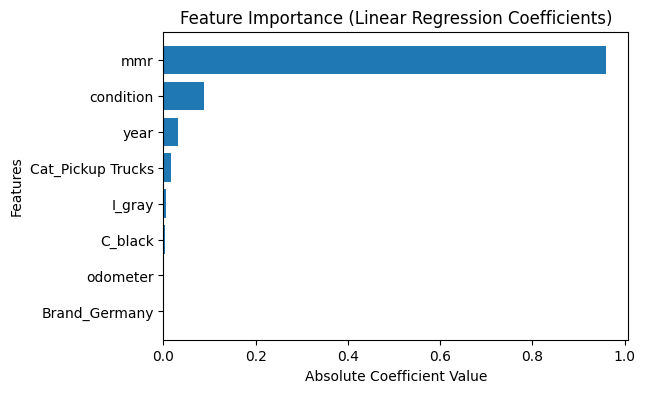

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Extract feature names and model coefficients
feature_names = X.columns
coefficients = model.coef_

# Create a DataFrame for feature importance
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Absolute Coefficient': np.abs(coefficients)
}).sort_values(by='Absolute Coefficient', ascending=False)

# Print the feature importance DataFrame
print("Feature Importance DataFrame:")
print(feature_importance_df)

# Plot the feature importance
plt.figure(figsize=(6, 4))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Absolute Coefficient'])
plt.xlabel('Absolute Coefficient Value')  # Label for the x-axis
plt.ylabel('')  # Label for the y-axis
plt.title('Feature Importance (Linear Regression Coefficients)')  # Title of the plot
plt.gca().invert_yaxis()  # Ensure the most important feature is at the top
plt.show()

##RandomForesrt Model

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Creating and training the RandomForest Regressor model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions using RandomForest Regressor
y_rf_pred = rf_model.predict(X_test)

# Calculating metrics for RandomForest Regressor
rf_mse = mean_squared_error(y_test, y_rf_pred).round(4)
rf_r2 = round(r2_score(y_test, y_rf_pred), 4)
rf_mae = mean_absolute_error(y_test, y_rf_pred).round(4)

# Displaying MSE and R-squared value for RandomForest model
print("Mean Squared Error (MSE):", rf_mse)
print("R-squared (R2) Score:", rf_r2)
print("Mean Absolute Error (MAE):", rf_mae)

Mean Squared Error (MSE): 0.0285
R-squared (R2) Score: 0.9716
Mean Absolute Error (MAE): 0.1128


**Feature Importance of Random Forest**

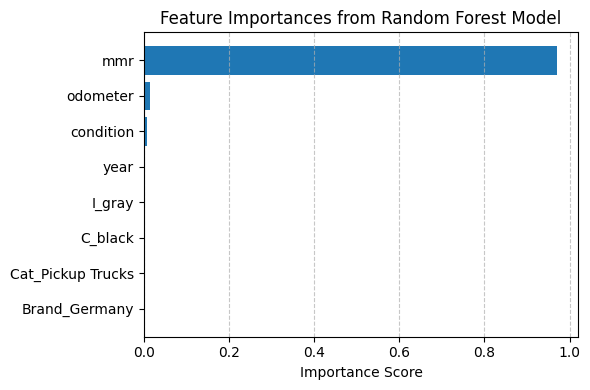

In [ ]:
# Getting feature importances
feature_importances = rf_model.feature_importances_

# Matching feature importances with column names and sorting them
importance_dict = dict(zip(X_train.columns, feature_importances))
sorted_importance = sorted(importance_dict.items(), key=lambda x: x[1], reverse=True)

# Extracting the features and their importance scores for chart plotting
features, importances = zip(*sorted_importance)

# Plotting feature importances
plt.figure(figsize=(6, 4))
plt.barh(features, importances)
plt.gca().invert_yaxis()  # Invert y-axis to display the highest importance at the top
plt.xlabel('Importance Score')
plt.ylabel('', fontsize=14)
plt.title('Feature Importances from Random Forest Model')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

{'max_depth': 30,
 'min_samples_leaf': 5,
 'min_samples_split': 12,
 'n_estimators': 100}

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Adjusting the hyperparameters
rf2_model = RandomForestRegressor(n_estimators=100, max_depth=30,
                                  min_samples_split=12, min_samples_leaf=5,
                                  random_state=42)
rf2_model.fit(X_train, y_train)

# Predictions using the adjusted RandomForest Regressor
y2_rf_pred = rf2_model.predict(X_test)

# Calculating metrics for RandomForest Regressor
rf2_mse = mean_squared_error(y_test, y2_rf_pred).round(4)
rf2_r2 = round(r2_score(y_test, y2_rf_pred), 4)
rf2_mae = mean_absolute_error(y_test, y2_rf_pred).round(4)

# Displaying MSE and R-squared value for RandomForest model
print("Mean Squared Error (MSE):", rf2_mse)
print("R-squared (R2) Score:", rf2_r2)
print("Mean Absolute Error (MAE):", rf2_mae)

Mean Squared Error (MSE): 0.0268
R-squared (R2) Score: 0.9733
Mean Absolute Error (MAE): 0.1086


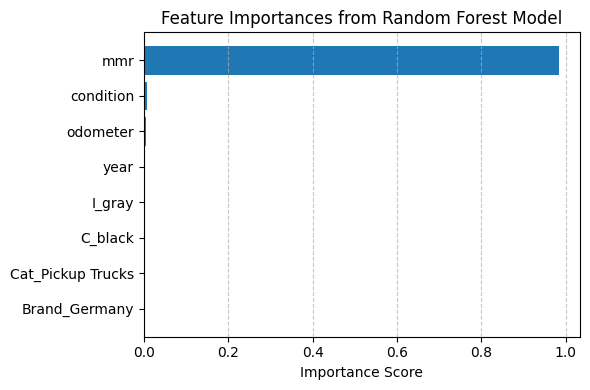

In [ ]:
# Getting feature importances
feature_importances = rf2_model.feature_importances_

# Matching feature importances with column names and sorting them
importance_dict = dict(zip(X_train.columns, feature_importances))
sorted_importance = sorted(importance_dict.items(), key=lambda x: x[1], reverse=True)

# Extracting the features and their importance scores for chart plotting
features, importances = zip(*sorted_importance)

# Plotting feature importances
plt.figure(figsize=(6, 4))
plt.barh(features, importances)
plt.gca().invert_yaxis()  # Invert y-axis to display the highest importance at the top
plt.xlabel('Importance Score')
plt.ylabel('', fontsize=14)
plt.title('Feature Importances from Random Forest Model')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
import numpy as np

# Model configuration
rf_model_cv = RandomForestRegressor(n_estimators=150, max_depth=10, min_samples_split=10, min_samples_leaf=4, random_state=42)

# Performing 10-fold cross-validation
cv_scores = cross_val_score(rf_model_cv, X_train, y_train, cv=5, scoring='r2')

# Calculate average R-squared across all folds
average_r2 = np.mean(cv_scores)

# Displaying the average R-squared value from cross-validation
average_r2.round(4)

0.9734230681828977

##Gradient Boosting Model

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

# Configuring and training the Gradient Boosting model
gb_model = GradientBoostingRegressor(n_estimators=150, max_depth=5,
                                     min_samples_split=5, min_samples_leaf=3,
                                     random_state=42)
gb_model.fit(X_train, y_train)

# Predictions and evaluation
y_gb_pred = gb_model.predict(X_test)

# Calculating metrics for RandomForest Regressor
gb_mse = mean_squared_error(y_test, y_rf_pred).round(4)
gb_r2 = round(r2_score(y_test, y_rf_pred), 4)
gb_mae = mean_absolute_error(y_test, y_pred).round(4)

# Displaying MSE and R-squared value for RandomForest model
print("Mean Squared Error (MSE):", gb_mse)
print("R-squared (R2) Score:", gb_r2)
print("Mean Absolute Error (MAE):", gb_mae)

Mean Squared Error (MSE): 0.0285
R-squared (R2) Score: 0.9716
Mean Absolute Error (MAE): 0.1093


##Compare the three models

The Linear Regression model demonstrates the strongest performance among the three, with a low MSE of 0.0272 and a high R-squares score of 0.9729. Indicate that Linear Regression effectively captures the relationship between features and the target variable, making accurate predictions with minimal errors. The low MAE of 0.1093 further supports its suitability for this dataset, where the relationship between variables appears predominantly linear.

In comparison, the Random Forest Regressor performs reasonably well, achieving an R² score comparable to Linear Regression. However, its significantly higher error metrics suggest challenges in adapting to the dataset. Random Forest, despite its ability to capture non-linear patterns, may face issues such as scaling errors or suboptimal tuning, which could limit its effectiveness for this specific problem.

The Gradient Boosting Regressor exhibits similar performance to the Random Forest model, achieving a comparable R² score but showing no improvement in error metrics. While Gradient Boosting is often better suited for capturing complex patterns, it does not outperform Linear Regression here. Overall, Linear Regression proves to be the most efficient and accurate model, likely due to the dataset’s predominantly linear structure.

##Feature Importance:

Analyze feature importance to understand which features contribute the most to the model's predictions.
Consider removing less important features to simplify the model.

The Linear Regression model identifies mmr as the most significant feature, with a coefficient that far exceeds all others, indicating its strong linear relationship with the target variable. Features such as condition and year contribute moderately, while others like odometer, Brand_Germany, and Cat_Pickup Trucks have minimal impact. This shows that the model heavily relies on mmr to make accurate predictions, with other features playing a secondary role.

In the Random Forest and Gradient Boosting model, mmr again dominates the feature importance scores, highlighting its critical role in predictions. While condition and odometer provide smaller contributions, most other features have negligible impact on the model's performance. This further reinforces the importance of mmr, as it remains the most influential feature in a non-linear model setting.

This consistency across models underscores the pivotal role of mmr, making it the primary factor driving accurate predictions regardless of the modeling technique.

#6. Answering Business Questions and Providing Insights

**Business Question 1: What are the key factors that influence the selling price of used vehicles?**

*Key Insights:*

**MMR Value:** The most significant predictor of selling price. Vehicles sold close to their MMR value, emphasizing its reliability as a pricing benchmark.
- Action: Use MMR as a reference; price slightly above for high demand or unique features, and closer to MMR for slower-moving inventory.

**Vehicle Condition:** Higher condition scores lead to 10–15% higher selling prices.
- Action: Invest in minor repairs and refurbishments to boost condition ratings and perceived value.

**Age and Depreciation:** Steep depreciation in the first five years; 3–7-year-old vehicles offer the best balance of value and affordability.
- Action: Stock 3–7-year-old vehicles and highlight affordability to attract buyers.

**Body Type Preferences:** SUVs and pickup trucks fetch higher prices; sedans dominate volume sales.
- Action: Tailor inventory to regional preferences and promote key features like towing capacity for trucks.

**Color Preferences:** Neutral colors (black, silver, white) sell faster and at higher prices, while rare colors have niche appeal.
- Action: Focus inventory on high-demand colors and use targeted campaigns for rare ones.

---------
**Business Question 2: How can we accurately predict the selling price of a vehicle based on its features?**

*Key Insights:*

- The Random Forest Regressor achieved a high R² score (0.973), indicating it is a robust predictive model for estimating selling prices.

- The model incorporates both linear and non-linear relationships among variables, making it suitable for the dataset's complexity.

- Feature importance analysis reveals that `MMR`, `year` and `condition` are the most influential predictors.

*Actionable Insight:*

- Deploy the Random Forest model in dealership operations to provide accurate price estimates for trade-ins and sales negotiations.

- Simplify the model by focusing on the most important features (e.g., MMR, condition, and year) for operational ease without significantly sacrificing accuracy.

-----------

**Business Question 3: What trends and patterns exist in vehicle sales over time, and how do these trends vary across different segments?**

*Key Insights:*

- Economic Trends: A noticeable dip in the availability of 2008–2009 models reflects the impact of the 2008 financial crisis, suggesting economic events significantly influence vehicle sales.

- Transmission Type: Automatic transmission dominates the market (~96%), indicating strong consumer preference.

- Color and Interior Trends: Black exteriors and gray interiors are more popular and slightly increase perceived vehicle value.

*Actionable Insight:*

- Monitor broader economic conditions and their potential impacts on vehicle demand and pricing trends.

- Stock vehicles with automatic transmissions, as they align with dominant consumer preferences.

- Target marketing campaigns toward popular vehicle colors and interior styles, emphasizing these features to attract buyers.

***Summary of Expected Outcomes:***

- Enhanced Pricing Strategies:
By leveraging the predictive model, the dealership can set competitive yet profitable prices, reducing the risk of overpricing or underpricing vehicles.

- Streamlined Inventory Management: Prioritize stocking vehicles that align with consumer demand, such as pickup trucks, automatic transmissions, and popular color combinations.

- Data-Driven Decision Making: Incorporating insights from economic trends, vehicle features, and consumer preferences ensures a strategic approach to sales and marketing.